In [1]:
from pathlib import Path
import json
import time

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
PROJECT_DIR = Path("..").resolve()

TRAIN_DIR = PROJECT_DIR / "data" / "processed" / "train"
VAL_DIR = PROJECT_DIR / "data" / "processed" / "val"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Train path exists:", TRAIN_DIR.exists())
print("Validation path exists:", VAL_DIR.exists())

Train path exists: True
Validation path exists: True


In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20
SEED = 42

CLASS_NAMES = ["no_fall", "fall"]

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1123 files belonging to 2 classes.
Found 361 files belonging to 2 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10)
    ],
    name="data_augmentation"
)

In [7]:
custom_cnn = models.Sequential(
    [
        layers.Input(shape=(224, 224, 3)),

        data_augmentation,

        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ],
    name="custom_fall_cnn"
)

In [8]:
custom_cnn.summary()

Model: "custom_fall_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [10]:
train_no_fall_count = 684
train_fall_count = 439

total_train = train_no_fall_count + train_fall_count

class_weights = {
    0: total_train / (2 * train_no_fall_count),
    1: total_train / (2 * train_fall_count)
}

print(class_weights)

{0: 0.820906432748538, 1: 1.2790432801822325}


In [11]:
CUSTOM_CNN_PATH = MODELS_DIR / "best_custom_cnn.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CUSTOM_CNN_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [12]:
start_time = time.time()

custom_history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

training_time_seconds = time.time() - start_time

print("Training time in seconds:", training_time_seconds)
print("Training time in minutes:", training_time_seconds / 60)

Epoch 1/20


c:\Users\GArvit\Desktop\Fall Detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.6616 - auc: 0.6998 - loss: 0.6756 - precision: 0.5551 - recall: 0.6765
Epoch 1: val_loss improved from None to 0.68832, saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_custom_cnn.keras

Epoch 1: finished saving model to C:\Users\GArvit\Desktop\Fall Detection\models\best_custom_cnn.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 64s 824ms/step - accuracy: 0.6616 - auc: 0.6998 - loss: 0.6756 - precision: 0.5551 - recall: 0.6765 - val_accuracy: 0.5706 - val_auc: 0.4708 - val_loss: 0.6883 - val_precision: 0.3846 - val_recall: 0.1027 - learning_rate: 0.0010
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.6741 - auc: 0.7330 - loss: 0.6305 - precision: 0.5677 - recall: 0.6970
Epoch 2: val_loss did not improve from 0.68832
71/71 ━━━━━━━━━━━━━━━━━━━━ 59s 821ms/step - accuracy: 0.6741 - auc: 0.7330 - loss: 0.6305 - precision: 0.5677 - recall: 0.6970 - val_accuracy: 0.4044 - val_auc: 0.5583 - val_loss: 0.8247 - val_preci

In [13]:
best_custom_cnn = tf.keras.models.load_model(
    "../models/best_custom_cnn.keras"
)

In [14]:
custom_probabilities = best_custom_cnn.predict(val_ds).flatten()

custom_predicted_labels = (
    custom_probabilities >= 0.5
).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step


In [15]:
true_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_ds
]).astype(int)

In [16]:
print(
    classification_report(
        true_labels,
        custom_predicted_labels,
        target_names=["No Fall", "Fall"],
        digits=4
    )
)

              precision    recall  f1-score   support

     No Fall     0.5932    0.8884    0.7114       215
        Fall     0.3846    0.1027    0.1622       146

    accuracy                         0.5706       361
   macro avg     0.4889    0.4956    0.4368       361
weighted avg     0.5088    0.5706    0.4892       361



In [17]:
custom_cm = confusion_matrix(
    true_labels,
    custom_predicted_labels
)

print(custom_cm)

[[191  24]
 [131  15]]


In [1]:
print("true_labels" in globals())
print("custom_cnn_predicted_labels" in globals())
print("custom_cnn_cm" in globals())

False
False
False


In [2]:
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
PROJECT_DIR = Path("..").resolve()

VAL_DIR = PROJECT_DIR / "data" / "processed" / "val"
MODEL_PATH = PROJECT_DIR / "models" / "best_custom_cnn.keras"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(exist_ok=True)

print("Validation folder exists:", VAL_DIR.exists())
print("Model exists:", MODEL_PATH.exists())

Validation folder exists: True
Model exists: True


In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
CLASS_NAMES = ["no_fall", "fall"]

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    label_mode="binary",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Found 361 files belonging to 2 classes.


In [5]:
custom_cnn_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Custom CNN loaded")

Custom CNN loaded


In [6]:
custom_cnn_probabilities = custom_cnn_model.predict(
    val_ds
).flatten()

custom_cnn_predicted_labels = (
    custom_cnn_probabilities >= 0.5
).astype(int)

true_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in val_ds
]).astype(int)

custom_cnn_cm = confusion_matrix(
    true_labels,
    custom_cnn_predicted_labels
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step


In [7]:
custom_cnn_report = classification_report(
    true_labels,
    custom_cnn_predicted_labels,
    target_names=["No Fall", "Fall"],
    digits=4
)

print(custom_cnn_report)
print(custom_cnn_cm)

              precision    recall  f1-score   support

     No Fall     0.5932    0.8884    0.7114       215
        Fall     0.3846    0.1027    0.1622       146

    accuracy                         0.5706       361
   macro avg     0.4889    0.4956    0.4368       361
weighted avg     0.5088    0.5706    0.4892       361

[[191  24]
 [131  15]]


In [8]:
with open(
    RESULTS_DIR / "custom_cnn_metrics.txt",
    "w"
) as file:
    file.write("CUSTOM CNN CLASSIFICATION REPORT\n")
    file.write("=" * 40 + "\n\n")
    file.write(custom_cnn_report)

    file.write("\n\nCUSTOM CNN CONFUSION MATRIX\n")
    file.write("=" * 40 + "\n")
    file.write(str(custom_cnn_cm))

print("Saved custom_cnn_metrics.txt")

Saved custom_cnn_metrics.txt


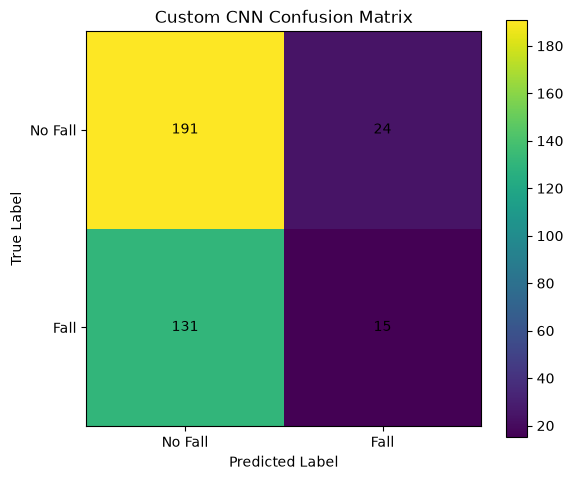

In [9]:
plt.figure(figsize=(6, 5))

plt.imshow(custom_cnn_cm)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["No Fall", "Fall"])
plt.yticks([0, 1], ["No Fall", "Fall"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            custom_cnn_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "custom_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print((RESULTS_DIR / "custom_cnn_metrics.txt").exists())
print((RESULTS_DIR / "custom_cnn_confusion_matrix.png").exists())

True
True
